## Kaggle Flight Data Analysis Python Project
Analysis and projections of various metrics (Airline, Destination, Arrival Time, etc) for flights in India from a Kaggle dataset using Python.

## Import Python Libraries
Importing Pandas, Numpy, MatPlotLib, and Seaborn for effective data maniuplation and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

## Load Dataset
Importing CSV file for Flight Data in India

In [5]:
df = pd.read_csv('airlines_flights_data.csv')

## Exploring Data Frames
Displaying data to understand data formmating and structure
We see that thrre are 300,152 rows with 11 columns; 4 are integers/floats and 7 are strings

In [12]:
df.info()
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   index             300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


## Data Cleaning
Removing redundant Index column

In [14]:
df_cleaned = df.drop(columns=['index'])
df_cleaned.head(12)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
5,Vistara,UK-945,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.33,1,5955
6,Vistara,UK-927,Delhi,Morning,zero,Morning,Mumbai,Economy,2.08,1,6060
7,Vistara,UK-951,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.17,1,6060
8,GO_FIRST,G8-334,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.17,1,5954
9,GO_FIRST,G8-336,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.25,1,5954


Checking for null or duplicate values

In [ ]:
df.isnull().sum()
## No null values found

index               0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [28]:
df[df.duplicated()] 
## No duplicate values found

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price


## Feature Engineering
Adding column that has price in USD.

In [33]:
df_cleaned['price (USD $)'] = (df_cleaned['price'] * .012).round(2)
df_cleaned[['price (USD $)']].head(12)

,price (USD $)
0,71.44
1,71.44
2,71.47
3,71.46
4,71.46
5,71.46
6,72.72
7,72.72
8,71.45
9,71.45


Adding column that has price per hour in USD.

In [32]:
df_cleaned['price per hour (USD $)'] = (df_cleaned['price (USD $)'] / df_cleaned['duration']).round(2)
df_cleaned[['price per hour (USD $)']].head(12)

,price per hour (USD $)
0,32.92
1,30.66
2,32.94
3,31.76
4,30.67
5,30.67
6,34.96
7,33.51
8,32.93
9,31.76


## Summary Statistics
Mean, Median, Quartiles, etc

In [24]:
df_cleaned.describe()

,duration,days_left,price,price (USD $),price per hour (USD $)
count,300153.000000,300153.000000,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523,250.676072,26.105617
std,7.191997,13.561004,22697.767366,272.373277,32.801169
min,0.830000,1.000000,1105.000000,13.260000,1.240000
25%,6.830000,15.000000,4783.000000,57.400000,5.520000
50%,11.250000,26.000000,7425.000000,89.100000,11.740000
75%,16.170000,38.000000,42521.000000,510.250000,34.710000
max,49.830000,49.000000,123071.000000,1476.850000,341.680000


## Analysis
Let's start by finding the airline frequencies in the dataset

In [ ]:
df_cleaned['airline'].value_counts()
## Looks like Vistara is the most popular and SpiceJet is the least popular. 
## Let's graph this to get a better visualization of the spread.

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

Airline frequency bar graph

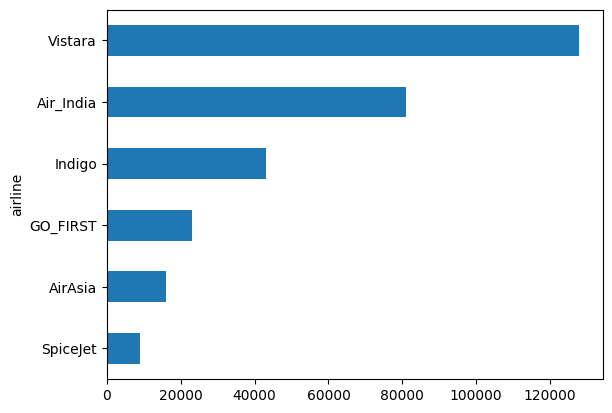

In [41]:
df_cleaned['airline'].value_counts(ascending = True).plot.barh()
plt.show()